# BusinessLens - *Sales & Business Performance Analytics*

### Beeskilled Internship Capstone Project

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
df= pd.read_csv("raw_dataset.csv")

In [3]:
df.head(10)

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Germany,Carretera,NaN,1513.0,3,350,529550.0,0.0,529550.0,393380.0,136170.0,01-Dec-14,12,December,2014
1,Government,Germany,Paseo,NaN,1006.0,10,350,352100.0,0.0,352100.0,261560.0,90540.0,01-Jun-14,6,June,2014
2,Government,Canada,Paseo,NaN,1725.0,10,350,603750.0,0.0,603750.0,448500.0,155250.0,01-Nov-13,11,November,2013
3,Government,Germany,Paseo,NaN,1513.0,10,350,529550.0,0.0,529550.0,393380.0,136170.0,01-Dec-14,12,December,2014
4,Government,Germany,Velo,NaN,1006.0,120,350,352100.0,0.0,352100.0,261560.0,90540.0,01-Jun-14,6,June,2014
5,Government,France,VTT,NaN,1527.0,250,350,534450.0,0.0,534450.0,397020.0,137430.0,01-Sep-13,9,September,2013
6,Government,France,Amarilla,NaN,2750.0,260,350,962500.0,0.0,962500.0,715000.0,247500.0,01-Feb-14,2,February,2014
7,Government,Mexico,Carretera,Low,1210.0,3,350,423500.0,4235.0,419265.0,314600.0,104665.0,01-Mar-14,3,March,2014
8,Government,Mexico,Carretera,Low,1397.0,3,350,488950.0,4889.5,484060.5,363220.0,120840.5,01-Oct-14,10,October,2014
9,Government,France,Carretera,Low,2155.0,3,350,754250.0,7542.5,746707.5,560300.0,186407.5,01-Dec-14,12,December,2014


In [4]:
df.tail(10)

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
690,Channel Partners,France,Paseo,High,1393.0,10,12,16716.0,2340.24,14375.76,4179.0,10196.76,01-Oct-14,10,October,2014
691,Midmarket,Canada,Paseo,High,2470.0,10,15,37050.0,5187.00,31863.00,24700.0,7163.00,01-Sep-13,9,September,2013
692,Midmarket,Canada,Paseo,High,1743.0,10,15,26145.0,3660.30,22484.70,17430.0,5054.70,01-Oct-13,10,October,2013
693,Channel Partners,United States of America,Paseo,High,2914.0,10,12,34968.0,4895.52,30072.48,8742.0,21330.48,01-Oct-14,10,October,2014
694,Channel Partners,Canada,Paseo,High,2222.0,10,12,26664.0,3732.96,22931.04,6666.0,16265.04,01-Nov-13,11,November,2013
695,Midmarket,Canada,Paseo,High,1614.0,10,15,24210.0,3631.50,20578.50,16140.0,4438.50,01-Apr-14,4,April,2014
696,Midmarket,Canada,Paseo,High,2559.0,10,15,38385.0,5757.75,32627.25,25590.0,7037.25,01-Aug-14,8,August,2014
697,Enterprise,Germany,Paseo,High,1085.0,10,125,135625.0,20343.75,115281.25,130200.0,-14918.75,01-Oct-14,10,October,2014
698,Midmarket,Germany,Paseo,High,1175.0,10,15,17625.0,2643.75,14981.25,11750.0,3231.25,01-Oct-14,10,October,2014
699,Channel Partners,United States of America,Paseo,High,914.0,10,12,10968.0,1645.20,9322.80,2742.0,6580.80,01-Dec-14,12,December,2014


## Dataset Inspection & Understanding

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Segment              700 non-null    object 
 1   Country              700 non-null    object 
 2   Product              700 non-null    object 
 3   Discount Band        647 non-null    object 
 4   Units Sold           700 non-null    float64
 5   Manufacturing Price  700 non-null    int64  
 6   Sale Price           700 non-null    int64  
 7   Gross Sales          700 non-null    float64
 8   Discounts            700 non-null    float64
 9   Sales                700 non-null    float64
 10  COGS                 700 non-null    float64
 11  Profit               700 non-null    float64
 12  Date                 700 non-null    object 
 13  Month Number         700 non-null    int64  
 14  Month Name           700 non-null    object 
 15  Year                 700 non-null    int

In [6]:
df.duplicated().sum()

np.int64(0)

### Categorical Variable Inspection

In [7]:
df['Country'].value_counts()

Country
Germany                     140
Canada                      140
France                      140
Mexico                      140
United States of America    140
Name: count, dtype: int64

In [8]:
df['Segment'].value_counts()

Segment
Government          300
Midmarket           100
Channel Partners    100
Enterprise          100
Small Business      100
Name: count, dtype: int64

In [9]:
df['Year'].value_counts()

Year
2014    525
2013    175
Name: count, dtype: int64

In [10]:
df['Product'].value_counts()

Product
Paseo        202
Velo         109
VTT          109
Amarilla      94
Carretera     93
Montana       93
Name: count, dtype: int64

In [11]:
df['Discount Band'].value_counts()

Discount Band
High      245
Medium    242
Low       160
Name: count, dtype: int64

### Numerical Variable Summary

In [12]:
df.describe().round(2)

,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Month Number,Year
count,700.00,700.00,700.00,700.00,700.00,700.00,700.00,700.00,700.00,700.00
mean,1608.29,96.48,118.43,182759.43,13150.35,169609.07,145475.21,24133.86,7.90,2013.75
std,867.43,108.60,136.78,254262.28,22962.93,236726.35,203865.51,42760.63,3.38,0.43
min,200.00,3.00,7.00,1799.00,0.00,1655.08,918.00,-40617.50,1.00,2013.00
25%,905.00,5.00,12.00,17391.75,800.32,15928.00,7490.00,2805.96,5.75,2013.75
50%,1542.50,10.00,20.00,37980.00,2585.25,35540.20,22506.25,9242.20,9.00,2014.00
75%,2229.12,250.00,300.00,279025.00,15956.34,261077.50,245607.50,22662.00,10.25,2014.00
max,4492.50,260.00,350.00,1207500.00,149677.50,1159200.00,950625.00,262200.00,12.00,2014.00


## Data Cleaning & Preparation

In [13]:
# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"], format="%d-%b-%y")

df["Date"].head()

0   2014-12-01
1   2014-06-01
2   2013-11-01
3   2014-12-01
4   2014-06-01
Name: Date, dtype: datetime64[ns]

In [14]:
# Replace missing Discount Band values where no discount was applied
df.loc[(df["Discount Band"].isna()) & (df["Discounts"] == 0), "Discount Band"] = "None"

print(df["Discount Band"].value_counts(dropna=False))

Discount Band
High      245
Medium    242
Low       160
None       53
Name: count, dtype: int64


In [15]:
df.isnull().sum()

Segment                0
Country                0
Product                0
Discount Band          0
Units Sold             0
Manufacturing Price    0
Sale Price             0
Gross Sales            0
Discounts              0
Sales                  0
COGS                   0
Profit                 0
Date                   0
Month Number           0
Month Name             0
Year                   0
dtype: int64

In [16]:
df.describe().round(2)

,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Year
count,700.00,700.00,700.00,700.00,700.00,700.00,700.00,700.00,700,700.00,700.00
mean,1608.29,96.48,118.43,182759.43,13150.35,169609.07,145475.21,24133.86,2014-04-28 21:36:00,7.90,2013.75
min,200.00,3.00,7.00,1799.00,0.00,1655.08,918.00,-40617.50,2013-09-01 00:00:00,1.00,2013.00
25%,905.00,5.00,12.00,17391.75,800.32,15928.00,7490.00,2805.96,2013-12-24 06:00:00,5.75,2013.75
50%,1542.50,10.00,20.00,37980.00,2585.25,35540.20,22506.25,9242.20,2014-05-16 12:00:00,9.00,2014.00
75%,2229.12,250.00,300.00,279025.00,15956.34,261077.50,245607.50,22662.00,2014-09-08 12:00:00,10.25,2014.00
max,4492.50,260.00,350.00,1207500.00,149677.50,1159200.00,950625.00,262200.00,2014-12-01 00:00:00,12.00,2014.00
std,867.43,108.60,136.78,254262.28,22962.93,236726.35,203865.51,42760.63,NaN,3.38,0.43


In [17]:
# Save Cleaned Dataset
df.to_csv("cleaned_dataset.csv", index=False)

## Exploratory Data Analysis

### Sales Trend Analysis

In [18]:
# Total sales by year
yearly_sales = df.groupby("Year")["Sales"].sum().round(2)

yearly_sales

Year
2013    26415255.51
2014    92311094.75
Name: Sales, dtype: float64

In [19]:
# Total sales by month
monthly_sales = (
    df.groupby(["Month Number", "Month Name"])["Sales"].sum().reset_index().sort_values("Month Number")
)

monthly_sales

,Month Number,Month Name,Sales
0,1,January,6607761.68
1,2,February,7297531.39
2,3,March,5586859.87
3,4,April,6964775.07
4,5,May,6210211.06
5,6,June,9518893.82
6,7,July,8102920.18
7,8,August,5864622.42
8,9,September,10882697.27
9,10,October,21671431.02


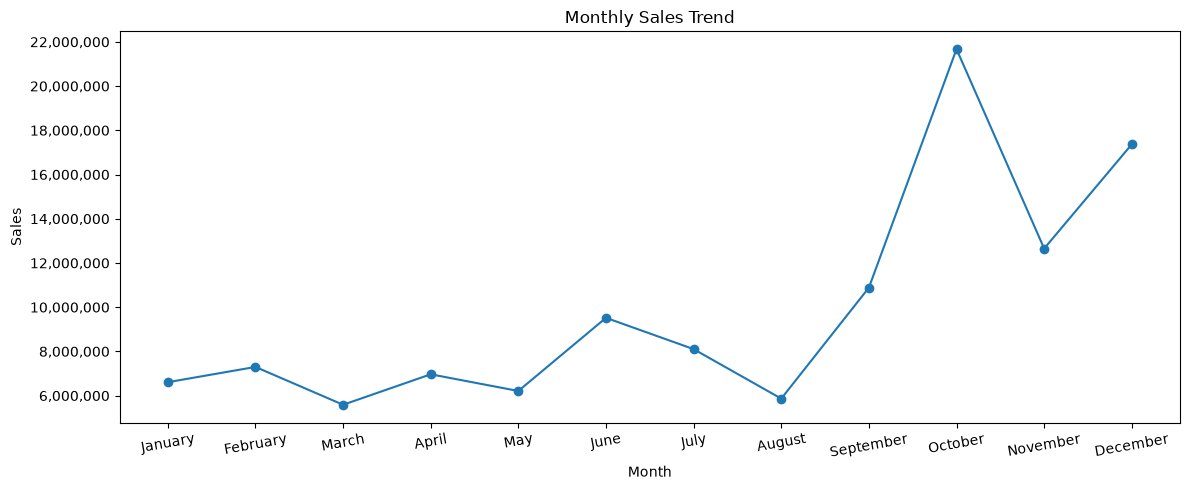

In [20]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_sales["Month Name"],monthly_sales["Sales"],marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=10)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

### Product Sales Analysis

In [21]:
# Total sales by product
product_sales = (df.groupby("Product")["Sales"].sum().sort_values(ascending=False).round(2))

product_sales

Product
Paseo        33011143.95
VTT          20511921.02
Velo         18250059.46
Amarilla     17747116.06
Montana      15390801.88
Carretera    13815307.88
Name: Sales, dtype: float64

In [22]:
# Total profit by product
product_profit = (df.groupby("Product")["Profit"].sum().sort_values(ascending=False).round(2))

product_profit

Product
Paseo        4797437.95
VTT          3034608.02
Amarilla     2814104.06
Velo         2305992.46
Montana      2114754.88
Carretera    1826804.88
Name: Profit, dtype: float64

In [23]:
# Combine sales and profit by product
product_performance = pd.DataFrame({"Sales": product_sales,"Profit": product_profit})

product_performance

,Sales,Profit
Product,,
Amarilla,17747116.06,2814104.06
Carretera,13815307.88,1826804.88
Montana,15390801.88,2114754.88
Paseo,33011143.95,4797437.95
VTT,20511921.02,3034608.02
Velo,18250059.46,2305992.46


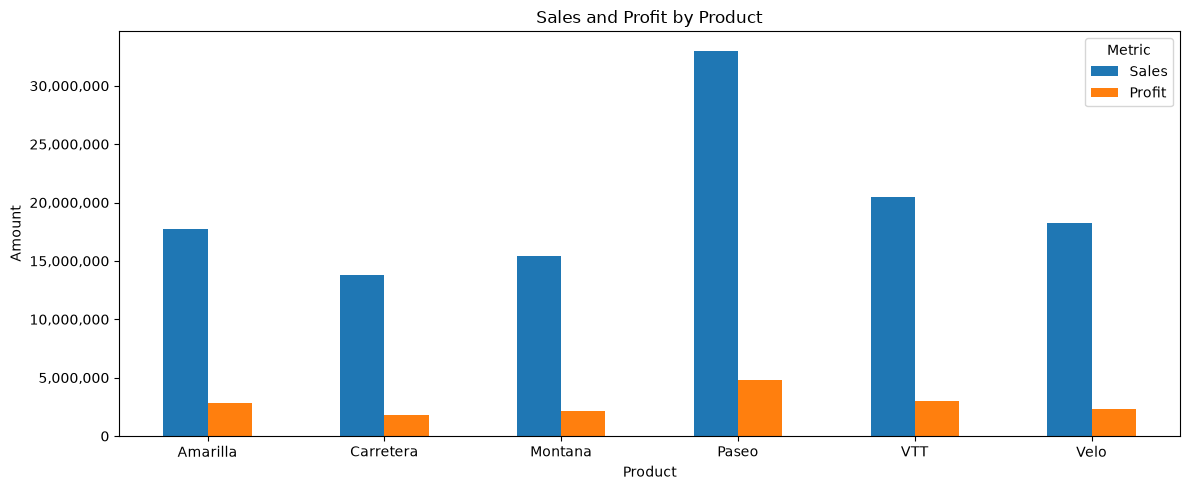

In [24]:
# Sales and profit by product
product_performance.plot(kind="bar",figsize=(12, 5))

plt.title("Sales and Profit by Product")
plt.xlabel("Product")
plt.ylabel("Amount")

plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}"))

plt.legend(title="Metric")
plt.tight_layout()
plt.show()

### Country Analysis

In [25]:
# Total sales by country
country_sales = (df.groupby("Country")["Sales"].sum().sort_values(ascending=False).round(2))

country_sales

Country
United States of America    25029830.16
Canada                      24887654.88
France                      24354172.28
Germany                     23505340.82
Mexico                      20949352.11
Name: Sales, dtype: float64

In [26]:
# Profit by country
country_profit = (df.groupby("Country")["Profit"].sum().sort_values(ascending=False).round(2))

country_profit

Country
France                      3781020.78
Germany                     3680388.82
Canada                      3529228.88
United States of America    2995540.66
Mexico                      2907523.11
Name: Profit, dtype: float64

In [27]:
# Combine sales and profit by country
country_performance = pd.DataFrame({"Sales": country_sales,"Profit": country_profit})

country_performance

,Sales,Profit
Country,,
Canada,24887654.88,3529228.88
France,24354172.28,3781020.78
Germany,23505340.82,3680388.82
Mexico,20949352.11,2907523.11
United States of America,25029830.16,2995540.66


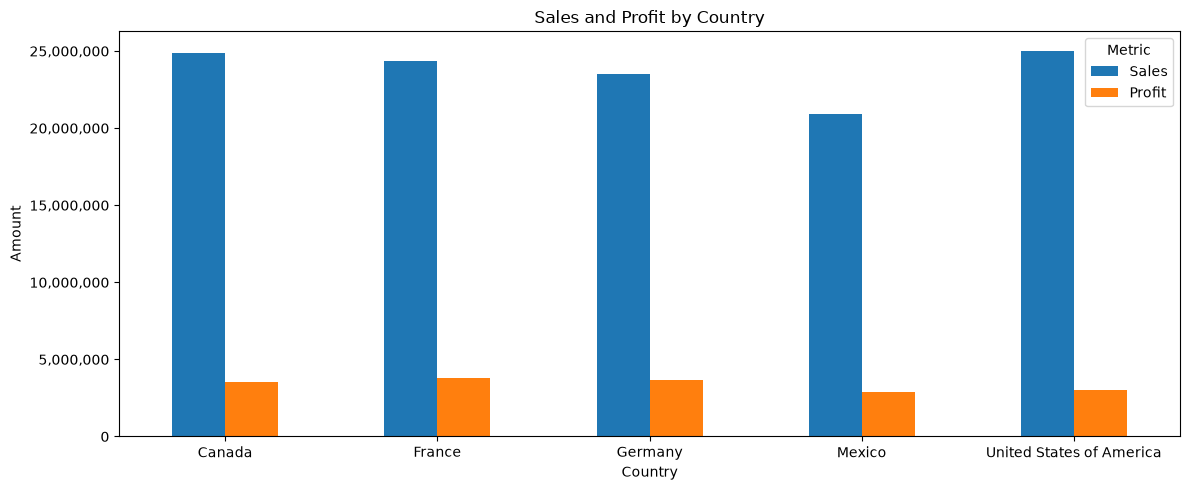

In [28]:
# Sales and profit by country
country_performance.plot(kind="bar",figsize=(12, 5))

plt.title("Sales and Profit by Country")
plt.xlabel("Country")
plt.ylabel("Amount")

plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}"))

plt.legend(title="Metric")
plt.tight_layout()
plt.show()

### Segment Analysis


In [29]:
# Sales by segment
segment_sales = (df.groupby("Segment")["Sales"].sum().sort_values(ascending=False).round(2))

segment_sales

Segment
Government          52504260.67
Small Business      42427918.50
Enterprise          19611694.38
Midmarket            2381883.08
Channel Partners     1800593.64
Name: Sales, dtype: float64

In [30]:
# Profit by segment
segment_profit = (df.groupby("Segment")["Profit"].sum().sort_values(ascending=False).round(2))

segment_profit

Segment
Government          11388173.17
Small Business       4143168.50
Channel Partners     1316803.14
Midmarket             660103.07
Enterprise           -614545.62
Name: Profit, dtype: float64

In [31]:
# Combine sales and profit by segment
segment_performance = pd.DataFrame({"Sales": segment_sales,"Profit": segment_profit})

segment_performance

,Sales,Profit
Segment,,
Channel Partners,1800593.64,1316803.14
Enterprise,19611694.38,-614545.62
Government,52504260.67,11388173.17
Midmarket,2381883.08,660103.07
Small Business,42427918.50,4143168.50


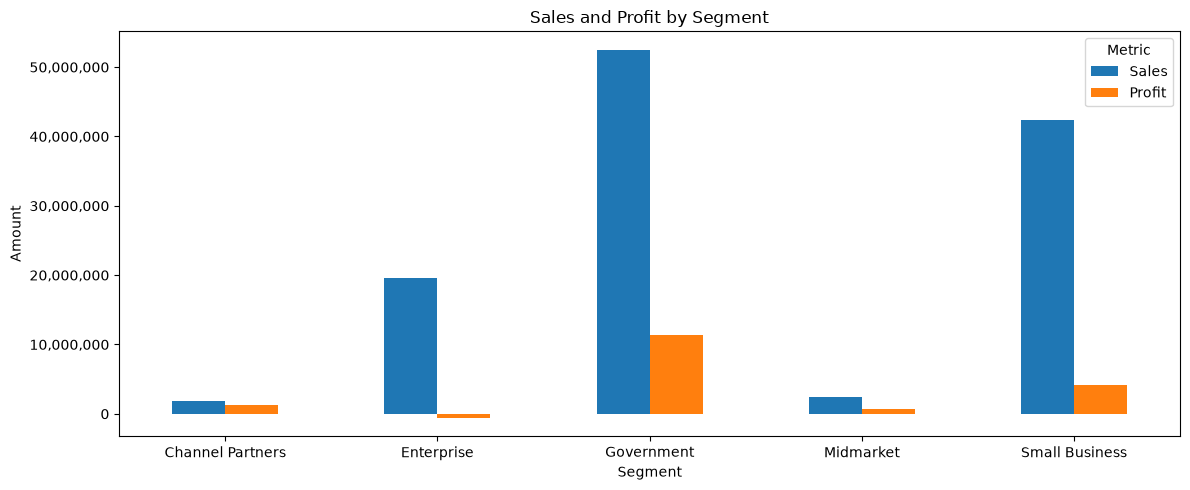

In [32]:
# Sales and profit by segment
segment_performance.plot(kind="bar",figsize=(12, 5))

plt.title("Sales and Profit by Segment")
plt.xlabel("Segment")
plt.ylabel("Amount")

plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}"))

plt.legend(title="Metric")
plt.tight_layout()
plt.show()

### Discount Analysis


In [33]:
# Sales by discount band
discount_sales = (df.groupby("Discount Band")["Sales"].sum().round(2))

discount_sales

Discount Band
High      37372486.72
Low       34629778.70
Medium    38780430.84
None       7943654.00
Name: Sales, dtype: float64

In [34]:
# Profit by discount band
discount_profit = (df.groupby("Discount Band")["Profit"].sum().round(2))

discount_profit

Discount Band
High      3388866.72
Low       6188857.70
Medium    5579522.84
None      1736455.00
Name: Profit, dtype: float64

In [35]:
# Combine sales and profit by discount band
discount_performance = pd.DataFrame({"Sales": discount_sales,"Profit": discount_profit})

discount_performance

,Sales,Profit
Discount Band,,
High,37372486.72,3388866.72
Low,34629778.70,6188857.70
Medium,38780430.84,5579522.84
None,7943654.00,1736455.00


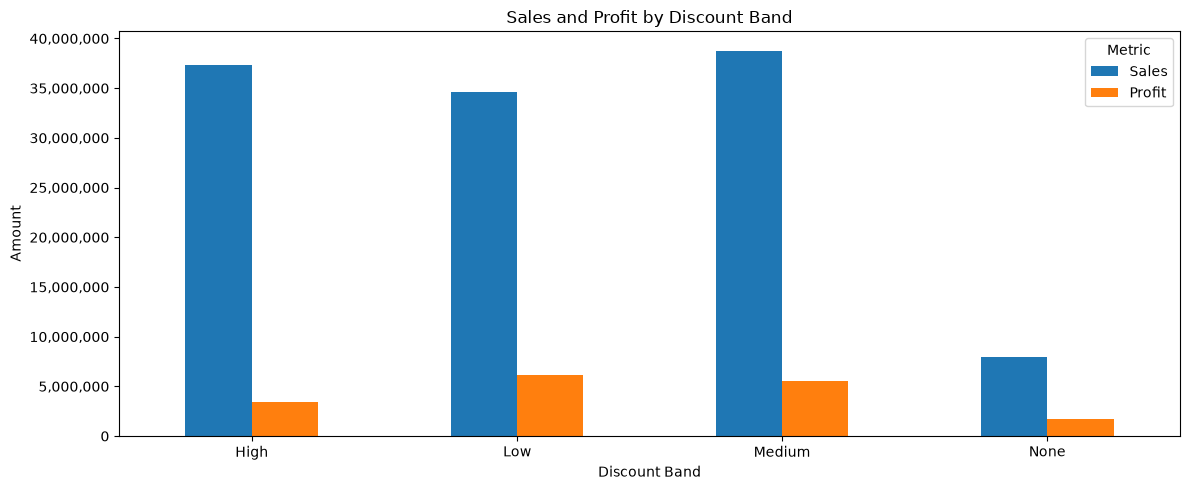

In [36]:
# Sales and profit by discount band
discount_performance.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Sales and Profit by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Amount")
plt.xticks(rotation=0)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)

plt.legend(title="Metric")
plt.tight_layout()
plt.show()

### EDA Summary

The exploratory analysis was performed to understand sales and profit performance across time, products, countries, customer segments, and discount bands.

### Key Findings

- **Yearly Performance:** Total sales were significantly higher in **2014 (92.31M)** compared with **2013 (26.42M)**. However, 2013 contains only partial-year data, so the two years should not be treated as directly comparable full-year periods.


- **Monthly Sales Trend:** Sales were strongest during **October**, followed by **December and November**, indicating higher sales activity toward the end of the year.

- **Product Performance:** **Paseo** was the top-performing product in both sales and profit, making it the strongest contributor to overall product performance.

- **Country Performance:** The **United States of America** generated the highest sales, while **France** generated the highest profit, showing that the highest-sales market was not the highest-profit market.

- **Segment Performance:** The **Government** segment generated the highest sales and profit. In contrast, the **Enterprise** segment generated substantial sales but recorded an overall negative profit.

- **Discount Performance:** The **Medium** discount band generated the highest sales, while the **Low** discount band generated the highest profit. This indicates that higher sales volume does not necessarily correspond to higher profit.

- **Overall Profitability:** The analysis shows that sales volume alone does not fully represent business performance. Product mix, customer segment, country, and discount levels also influence profitability.

These findings provide the foundation for the next phase of business analysis, where key performance metrics and actionable business insights will be examined in greater detail.